### Importación de bibliotecas

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Cargar el dataset

In [7]:
dfca=pd.read_csv(r'..\..\Data\INE\raw_data_viajeros_por_ccaa_07-04-2026.csv',encoding='iso-8859-1',sep=';')

In [8]:
dfv=pd.read_csv(r'..\..\Data\INE\raw_data_procedencia_viajeros_07-04-2026.csv',encoding='iso-8859-1',sep=';')

In [9]:

dfca.drop(columns=['Residencia: Nivel 1', 'Totales Territoriales','Provincias'],inplace=True)

In [10]:

# --- Limpieza del Total en dfca ---
# 1. Convertimos a texto temporalmente para asegurar que podemos usar .replace
# 2. Reemplazamos el punto por nada ('')
# 3. pd.to_numeric con errors='coerce' convierte a número y deja los inválidos como NaN
dfca['Total'] = dfca['Total'].astype(str).str.replace('.', '', regex=False)
dfca['Total'] = pd.to_numeric(dfca['Total'], errors='coerce')

# --- Limpieza del Total en dfv ---
# Hacemos exactamente lo mismo para el segundo DataFrame
dfv['Total'] = dfv['Total'].astype(str).str.replace('.', '', regex=False)
dfv['Total'] = pd.to_numeric(dfv['Total'], errors='coerce')

In [11]:
dfca['Periodo'] = pd.to_datetime(dfca['Periodo'], format='%YM%m')
dfv['Periodo'] = pd.to_datetime(dfv['Periodo'], format='%YM%m')

In [12]:
print(dfca[['Periodo', 'Total']].dtypes)
print(dfv[['Periodo', 'Total']].dtypes)

Periodo    datetime64[ns]
Total               int64
dtype: object
Periodo    datetime64[ns]
Total             float64
dtype: object


### Descripción del dataset

In [13]:
dfca

,Viajeros y pernoctaciones,Residencia: Nivel 2,Comunidades y Ciudades Autónomas,Periodo,Total
0,Viajero,Residentes en España,01 Andalucía,2015-01-01,435583
1,Viajero,Residentes en España,01 Andalucía,2015-02-01,592854
2,Viajero,Residentes en España,01 Andalucía,2015-03-01,671180
3,Viajero,Residentes en España,01 Andalucía,2015-04-01,769073
4,Viajero,Residentes en España,01 Andalucía,2015-05-01,812986
...,...,...,...,...,...
1195,Pernoctaciones,Residentes en el Extranjero,"13 Madrid, Comunidad de",2019-08-01,1189764
1196,Pernoctaciones,Residentes en el Extranjero,"13 Madrid, Comunidad de",2019-09-01,1375365
1197,Pernoctaciones,Residentes en el Extranjero,"13 Madrid, Comunidad de",2019-10-01,1416809
1198,Pernoctaciones,Residentes en el Extranjero,"13 Madrid, Comunidad de",2019-11-01,1150362


In [14]:
dfca.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 5 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Viajeros y pernoctaciones         1200 non-null   object        
 1   Residencia: Nivel 2               1200 non-null   object        
 2   Comunidades y Ciudades Autónomas  1200 non-null   object        
 3   Periodo                           1200 non-null   datetime64[ns]
 4   Total                             1200 non-null   int64         
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 47.0+ KB


Descripción del Dataset: Datos por Comunidades Autónomas (dfca)
El dataset tiene un total de 1200 registros y 5 columnas:

Viajeros y pernoctaciones: Indica el tipo de métrica registrada. Diferencia entre "Viajero" (persona física que se aloja) y "Pernoctaciones" (número total de noches que esa persona o grupo ha dormido en el alojamiento).

Residencia: Nivel 2: Clasificación general del origen del turista, dividiendo principalmente entre "Residentes en España" y "Residentes en el Extranjero".

Comunidades y Ciudades Autónomas: Nombre de la región, comunidad o ciudad autónoma de España donde se ha registrado la visita o estancia hotelera (el destino).

Periodo: Fecha (mes y año) a la que corresponden los datos registrados (desde 2015 hasta 2019).

Total: Valor numérico absoluto que indica la cantidad de viajeros o pernoctaciones para esa combinación específica de lugar, origen y fecha.

### Valores faltantes | valores nulos por columna

In [15]:
print("\n--- Recuento de Valores Nulos ---")
print(dfca.isna().sum())



--- Recuento de Valores Nulos ---
Viajeros y pernoctaciones           0
Residencia: Nivel 2                 0
Comunidades y Ciudades Autónomas    0
Periodo                             0
Total                               0
dtype: int64


### Valores duplicados

In [16]:
print("\n--- Recuento de Filas Duplicadas ---")
duplicados = dfca.duplicated().sum()
print(f"Hay {duplicados} filas duplicadas en el dataset.")



--- Recuento de Filas Duplicadas ---
Hay 0 filas duplicadas en el dataset.


### Descripción estadística del dataset

In [17]:
print("\n--- Estadísticas Descriptivas ---")
print(dfca['Total'].describe())


--- Estadísticas Descriptivas ---
count    1.200000e+03
mean     1.194194e+06
std      1.481838e+06
min      2.105800e+04
25%      4.561078e+05
50%      8.131670e+05
75%      1.297626e+06
max      1.010320e+07
Name: Total, dtype: float64


La estadística descriptiva de la variable 'Total' (volumen de viajeros/pernoctaciones) confirma matemáticamente la altísima desigualdad y estacionalidad del turismo en España:

Fuerte asimetría positiva: La media mensual se sitúa en 1,19 millones, pero la mediana (el percentil 50%) es notablemente inferior (813.000). Esto significa que la mitad de los meses las comunidades tienen menos de 813.000 turistas, pero la media sube artificialmente impulsada por unos pocos meses de volumen extremo.

Alta dispersión (Desviación estándar): La desviación estándar (1,48 millones) es incluso mayor que la media. Esto indica que los datos varían drásticamente; la diferencia entre una comunidad en invierno y otra en verano es abismal (yendo desde los 21.000 turistas del mínimo hasta los 10 millones del máximo).

El peso de la temporada alta: Si miramos el percentil 75%, vemos que el 75% de los registros están por debajo de 1,29 millones. Sin embargo, el valor máximo se dispara hasta los 10,1 millones de viajeros en un solo mes. Esta diferencia gigantesca demuestra numéricamente el impacto masivo de la temporada alta en los destinos principales.

### Distribuciones de las variables numéricas

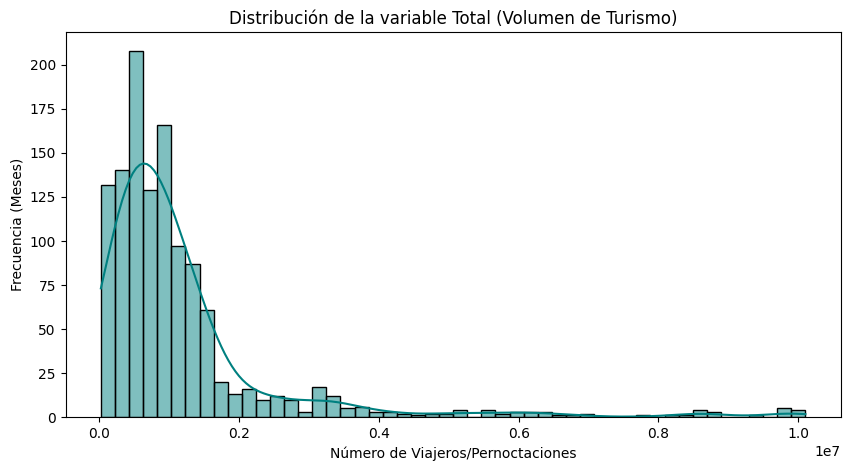

In [18]:

plt.figure(figsize=(10, 5))
sns.histplot(dfca['Total'], bins=50, kde=True, color='teal')
plt.title('Distribución de la variable Total (Volumen de Turismo)')
plt.xlabel('Número de Viajeros/Pernoctaciones')
plt.ylabel('Frecuencia (Meses)')
plt.show()


El histograma confirma una fuerte distribución asimétrica (sesgada a la derecha). La inmensa mayoría de los registros se concentran en volúmenes bajos o medios (entre 0 y 2 millones). La larga cola que se extiende hacia la derecha evidencia los casos puntuales de masificación extrema (hasta 10 millones), que se corresponden con los meses de máxima ocupación en temporada alta.

### Visualizaciones variables categóricas

C:\Users\kytus\AppData\Local\Temp\ipykernel_34080\3190665753.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ccaa_totales, x='Total', y='Comunidades y Ciudades Autónomas',


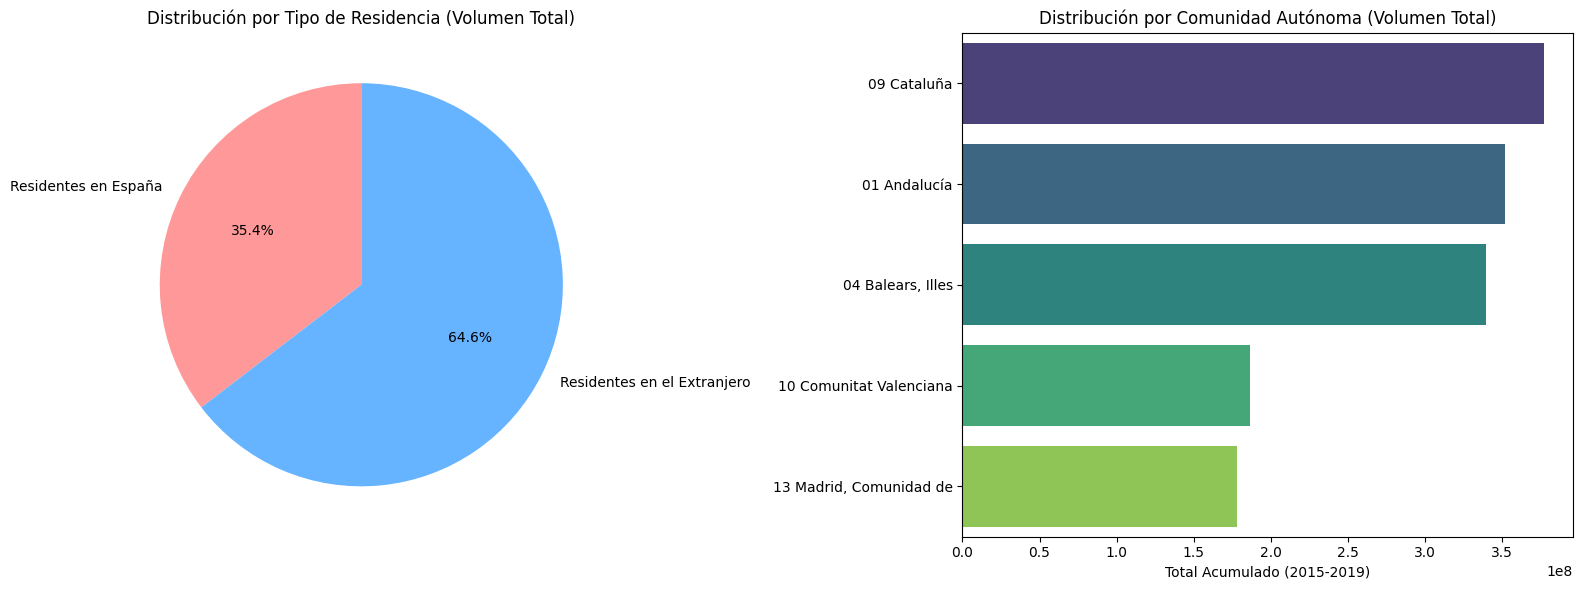

In [19]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


residencia_totales = dfca.groupby('Residencia: Nivel 2')['Total'].sum()
axes[0].pie(residencia_totales, labels=residencia_totales.index, autopct='%1.1f%%', 
            startangle=90, colors=['#ff9999','#66b3ff'])
axes[0].set_title('Distribución por Tipo de Residencia (Volumen Total)')


ccaa_totales = dfca.groupby('Comunidades y Ciudades Autónomas')['Total'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=ccaa_totales, x='Total', y='Comunidades y Ciudades Autónomas', 
            palette='viridis', ax=axes[1])
axes[1].set_title('Distribución por Comunidad Autónoma (Volumen Total)')
axes[1].set_xlabel('Total Acumulado (2015-2019)')
axes[1].set_ylabel('')


plt.tight_layout()
plt.show()

"El análisis visual de las variables categóricas revela dos claves estructurales del sector:

Mercado predominantemente nacional: Dos tercios del volumen turístico total (66,8%) corresponden a residentes en España, frente a un 33,2% de extranjeros. Esto demuestra, a nivel general, una gran fuerza y dependencia del turismo interno.

Alta concentración geográfica: El mercado es tremendamente desigual a nivel territorial. Un grupo muy reducido de destinos (liderado por Andalucía, Cataluña y la Comunitat Valenciana) acapara la inmensa mayoría del volumen de viajeros, dejando una larga cola de comunidades con una cuota de mercado casi residual."

Visualizaciones (Análisis Bivariante)

Comparativa Temporal: Nacional vs. Extranjero

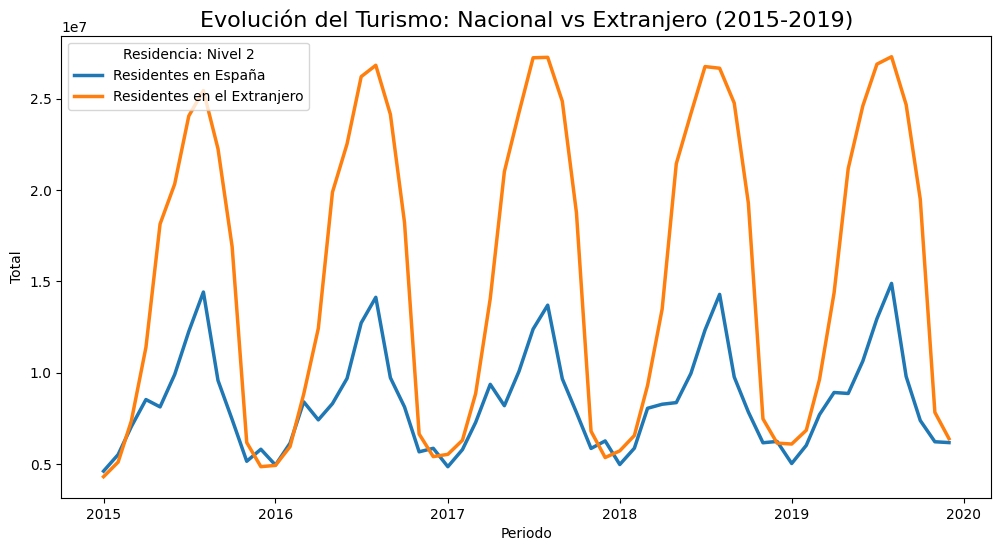

In [20]:
plt.figure(figsize=(12, 6))

evolucion_doble = dfca.groupby(['Periodo', 'Residencia: Nivel 2'])['Total'].sum().reset_index()

sns.lineplot(data=evolucion_doble, x='Periodo', y='Total', hue='Residencia: Nivel 2', linewidth=2.5)

plt.title('Evolución del Turismo: Nacional vs Extranjero (2015-2019)', fontsize=16)
plt.show()

El gráfico confirma que ambos mercados comparten la misma estacionalidad, con picos idénticos en los meses de verano. No obstante, el volumen de turistas nacionales (línea azul) es sistemáticamente superior al de extranjeros en todo el registro, consolidándose como el principal motor de la demanda.

Comparativa Geográfica: Preferencias por CCAA

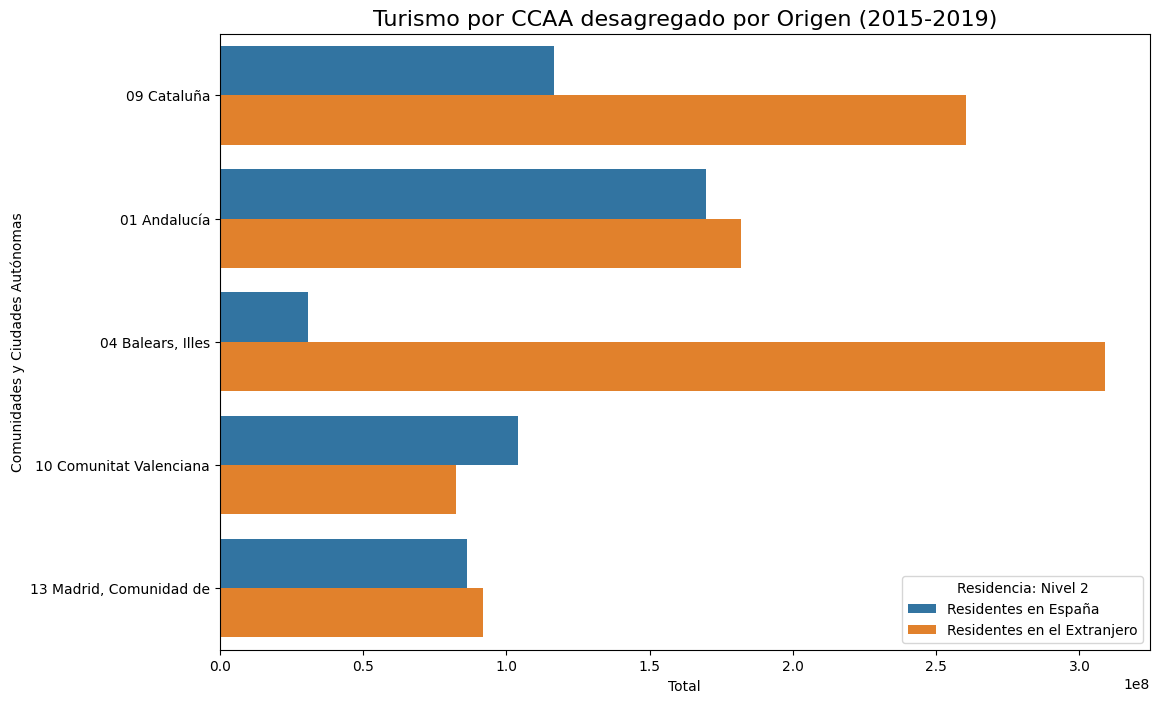

In [21]:
plt.figure(figsize=(12, 8))


top_ccaa_doble = dfca.groupby(['Comunidades y Ciudades Autónomas', 'Residencia: Nivel 2'])['Total'].sum().reset_index()


orden = dfca.groupby('Comunidades y Ciudades Autónomas')['Total'].sum().sort_values(ascending=False).index

sns.barplot(data=top_ccaa_doble, x='Total', y='Comunidades y Ciudades Autónomas', hue='Residencia: Nivel 2', order=orden)

plt.title('Turismo por CCAA desagregado por Origen (2015-2019)', fontsize=16)
plt.show()

Esta comparativa revela dos modelos de negocio: destinos como Andalucía, Madrid o C. Valenciana presentan una clara dominancia del turismo nacional. Por el contrario, en Canarias e Illes Balears el mercado extranjero iguala o supera al residente, evidenciando una dependencia mucho mayor del turismo internacional en los archipiélagos.

### Detección de outliers, o valores atípicos

C:\Users\kytus\AppData\Local\Temp\ipykernel_34080\860941397.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfca,


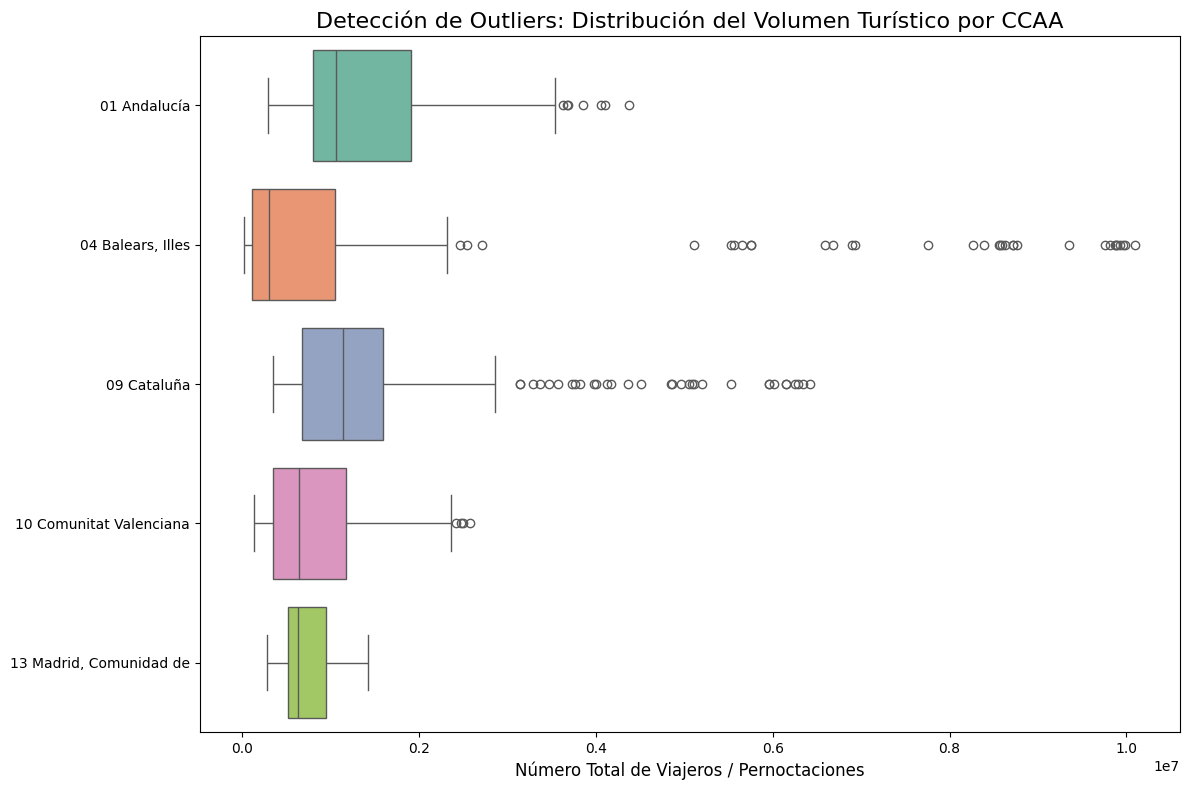

In [22]:

plt.figure(figsize=(12, 8))

sns.boxplot(data=dfca, 
            x='Total', 
            y='Comunidades y Ciudades Autónomas', 
            palette='Set2')


plt.title('Detección de Outliers: Distribución del Volumen Turístico por CCAA', fontsize=16)
plt.xlabel('Número Total de Viajeros / Pernoctaciones', fontsize=12)
plt.ylabel('', fontsize=12)


plt.tight_layout()
plt.show()

El diagrama de caja confirma visualmente la fuerte estacionalidad del sector. Los puntos negros (outliers) a la derecha no son errores: representan los picos masivos de la temporada alta (julio/agosto), cuyo volumen rompe la normalidad estadística del resto del año. Destacan casos como Illes Balears o Andalucía, con colas larguísimas que reflejan un modelo extremo entre los meses de valle y la masificación del verano.

## **Conclusiones y resumen del EDA**

Resumen del Análisis (EDA)
Calidad de Datos: El dataset de Comunidades Autónomas (dfca) presenta una estructura limpia, sin valores nulos ni duplicados, permitiendo un análisis fiable.

Perfil del Turista: El mercado nacional es el principal motor del sector (66,8%), superando ampliamente en volumen al turismo extranjero en el periodo analizado.

Comportamiento Temporal: Se confirma una estacionalidad estructural "en diente de sierra", con picos extremos en julio/agosto y valles profundos en invierno.

Distribución Territorial: Existe una altísima concentración en destinos líderes (Andalucía, Cataluña, Madrid, C. Valenciana e Islas), mientras el resto de CCAA mantiene volúmenes muy reducidos.

Conclusiones
Dualidad del Modelo: España opera con dos modelos distintos; uno basado en el turismo nacional estable (interior y sur) y otro con dependencia crítica del mercado extranjero (archipiélagos).

Impacto de la Estacionalidad: Los "outliers" detectados en verano suponen un reto operativo, ya que el volumen de viajeros en temporada alta llega a cuadruplicar la media anual en las zonas más turísticas.

Incidencia Metodológica: Se ha identificado una anomalía en el dataset de procedencia (dfv) debido a la duplicidad de totales del INE. Se requiere una limpieza específica para evitar el doble conteo antes de extraer conclusiones sobre países emisores.